In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Linear regression using `scikit-learn`

In this notebook, we will demonstrate the use of scikit-learn for solving linear regression problems.

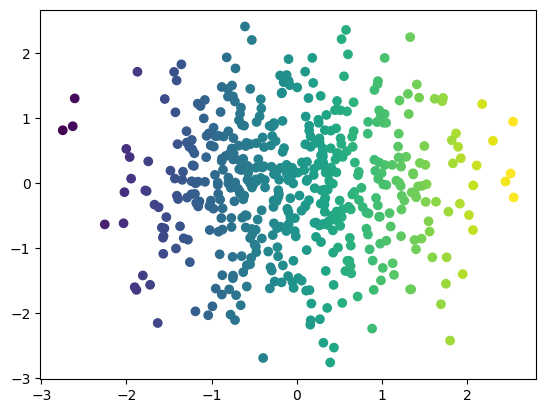

In [2]:
X,y = make_regression(
    n_samples=500,
    n_features=2,
    n_informative=1,
    shuffle=False
)

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

We will have a look at the regression models, and in particular Linear Regression, but the same syntax applies to other models as well.

You can find a list of available models at https://scikit-learn.org/stable/. 

In general, you can instantiate a model using the constructor, and specify some parameters in the following way:
```python
model = ModelName(
    parameter = value,
    other_parameter = other_value
)
```

For `LinearRegression`, the list of possible parameters can be seen here: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression

For example, in order to specify that the intercept should *no* be fitted, you should specify:
```python
from sklearn.linear_model import LinearRegression

model = LinearRegression(
    fit_intercept = False
)
```
(By default, this value is set to `True`)


This creates a model, which is constructed and initialized.
Then, the model can be fit to data in the following way:
```python
model.fit(X,y)
```

After the model has been fitted, 
```python
model.predict(X)
```


Modify the cell below to fit a `LinearRegression` model to `X` and `y`, then predict `X` and plot it.

Model coefficients: [ 7.00300206e+01 -9.80803612e-15], intercept: 2.886579864025407e-15
Mean Absolute Error (Ridge): 2.3674784355165458e-14
R_2 1.0


Text(0.5, 1.0, 'Predicted values')

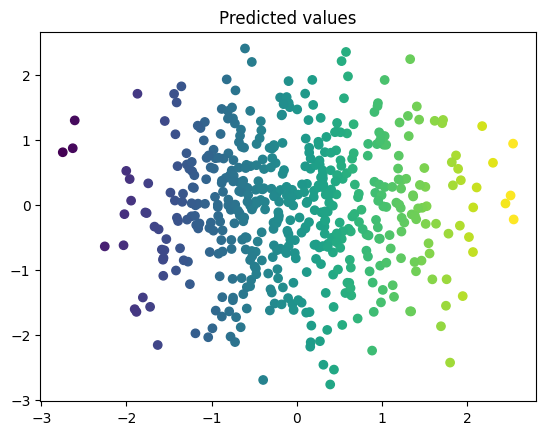

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print(f"Model coefficients: {model.coef_}, intercept: {model.intercept_}")

y_hat = model.predict(X)
mean_abs_error = np.mean(np.abs(y - y_hat))
print(f"Mean Absolute Error (Ridge): {mean_abs_error}")
r_2 = model.score(X,y)
print("R_2", r_2)
# Plot
plt.scatter(X[:,0], X[:,1], c=y_hat)
plt.title("Predicted values")

## $l_2$ regularization

In the cell below, switch the regressor for `Ridge`, and see the results.

Try changing some parameter (see on the documentation what is available: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html).

Model coefficients: [5.76912736e+01 3.73297545e-02], intercept: 0.0
Mean Absolute Error (Ridge): 9.730270192095151
R_2 (RR) 0.9689489192751869


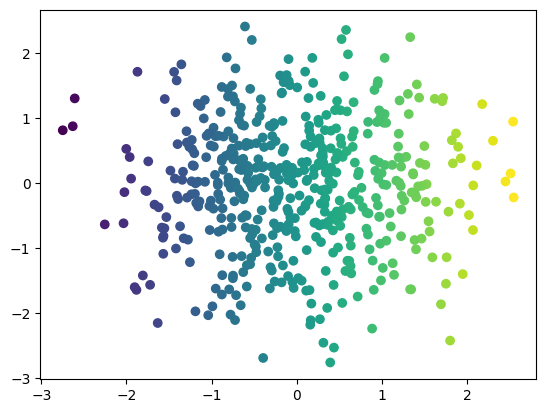

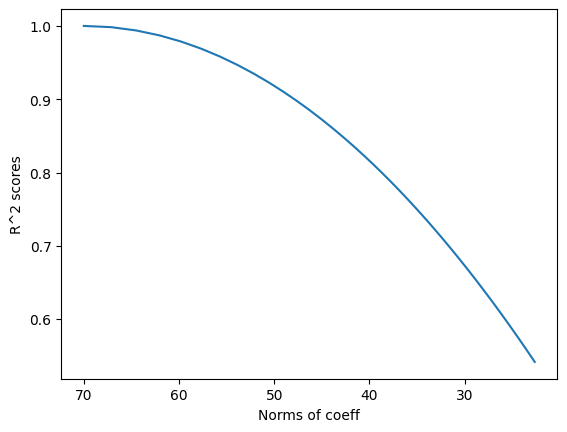

In [28]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha = 100, fit_intercept=False)
ridge_model.fit(X,y)
print(f"Model coefficients: {ridge_model.coef_}, intercept: {ridge_model.intercept_}")

y_ridge_hat = ridge_model.predict(X)
mean_abs_error_ridge = np.mean(np.abs(y - y_ridge_hat))
print(f"Mean Absolute Error (Ridge): {mean_abs_error_ridge}")
r_2_RR = ridge_model.score(X,y)
print("R_2 (RR)", r_2_RR)
# Plot
plt.scatter(X[:,0], X[:,1], c=y_ridge_hat)
plt.show()

r_2_scores = []
norms = []
for i in range(0,1000,20):
    ridge_model = Ridge(alpha = i, fit_intercept=False)
    ridge_model.fit(X,y)
    r_2_scores.append(ridge_model.score(X,y))
    norms.append(np.linalg.norm(ridge_model.coef_))
    
plt.plot(norms,r_2_scores)
plt.xlabel("Norms of coeff")
plt.ylabel("R^2 scores")
plt.gca().invert_xaxis()
plt.show()
    

## $l_1$ regularization

As above, but with `Lasso`.

(500, 2)
Model coefficients: [59.333688  0.      ], intercept: -0.16368136197215555
R_2 (Lasso) 0.9766707226023564


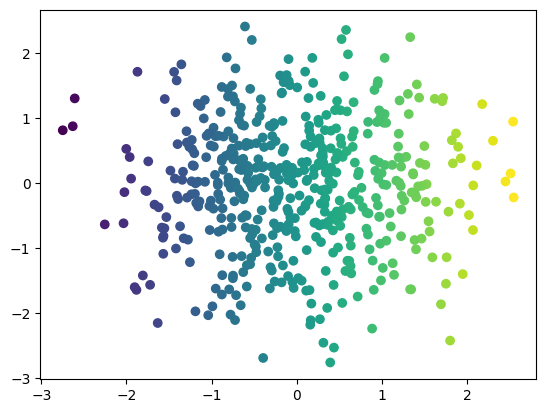

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha = 10)
lasso_model.fit(X,y)
print(X.shape)

print(f"Model coefficients: {lasso_model.coef_}, intercept: {lasso_model.intercept_}")

y_lasso_hat = lasso_model.predict(X)
r_2_lasso = lasso_model.score(X,y)
print("R_2 (Lasso)", r_2_lasso)

# Plot
plt.scatter(X[:,0], X[:,1], c=y_lasso_hat)
plt.show()

## Elastic-net

Elasticnet is a combination of l1 and l2 regularization. You can specify `alpha`, which is the sum of the coefficients for l1 and l2, as well as `l1_ratio`, which influences which term is more important, e.g., `l1_ratio` of 1 corresponds to only Lasso, 0 to only Ridge and 0.5 to equally weighted Lasso and Ridge.

Das Optimierungsproblem der **Elastic Net Regression** lautet:

$$
\min_{\boldsymbol{\beta}} \left\{ \underbrace{\sum_{i=1}^{n} (y_i - \boldsymbol{x}_i^T \boldsymbol{\beta})^2}_{\text{Quadratischer Fehler (RSS)}} + \lambda \left[ \underbrace{(1-\alpha) \sum_{j=1}^{p} \beta_j^2}_{\text{$L_2$ (Ridge)}} + \underbrace{\alpha \sum_{j=1}^{p} |\beta_j|}_{\text{$L_1$ (Lasso)}} \right] \right\}
$$

* $\boldsymbol{\beta}$: Vektor der Koeffizienten.
* $\lambda$: Gesamt-Regularisierungsstärke ($\lambda \ge 0$).
* $\alpha$: Mischungsparameter ($0 \le \alpha \le 1$).

Model coefficients: [45.27915756  0.        ], intercept: -0.3787517769836467
R_2 (Elastic Net) 0.8750856923681596


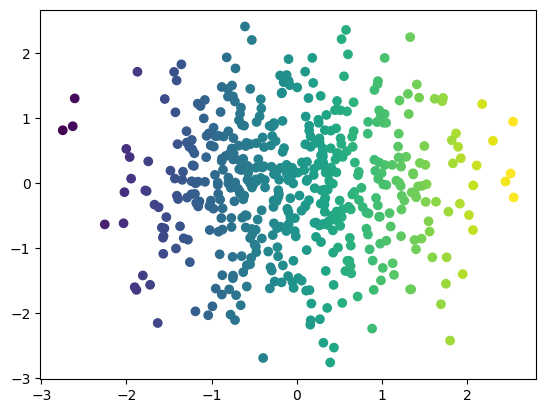

In [39]:
from sklearn.linear_model import ElasticNet

elastic_net_model = ElasticNet(alpha=1, l1_ratio = 0.5)
elastic_net_model.fit(X,y)


print(f"Model coefficients: {elastic_net_model.coef_}, intercept: {elastic_net_model.intercept_}")

y_elastic_net_hat = elastic_net_model.predict(X)
r_2_elastic_net = elastic_net_model.score(X,y)
print("R_2 (Elastic Net)", r_2_elastic_net)
# Plot
plt.scatter(X[:,0], X[:,1], c=y_elastic_net_hat)
plt.show()

Below, we compare the runtime of the different methods. 

Complete the other functions (the first is given) and compare the runtime. 

In [40]:
import timeit

X,y = make_regression(
    n_samples=1000,
    n_features=20,
    n_informative=30,
    shuffle=False
)


def fit_linear(X, y):
    mod = LinearRegression()
    mod.fit(X, y)
    return mod

def fit_l2(X, y):
    mod_l2 = Ridge(alpha=1)
    mod_l2.fit(X,y)
    return mod_l2

def fit_l1(X, y):
    mod_l1 = Lasso(alpha=1)
    mod_l1.fit(X,y)
    return mod_l1

def fit_elasticnet(X, y):
    mod_e = ElasticNet(alpha=1, l1_ratio=0.4)
    mod_e.fit(X,y)
    return mod_e



lin_time = timeit.timeit('fit_linear(X, y)', globals=globals(), number=50)
rid_time = timeit.timeit('fit_l2(X, y)', globals=globals(), number=50)
las_time = timeit.timeit('fit_l1(X, y)', globals=globals(), number=50)
ela_time = timeit.timeit('fit_elasticnet(X, y)', globals=globals(), number=50)

print(f"Linear regression       : {lin_time:.4f}s")
print(f"Ridge regression        : {rid_time:.4f}s")
print(f"Lasso regression        : {las_time:.4f}s")
print(f"Elasticnet regression   : {ela_time:.4f}s")

Linear regression       : 0.4042s
Ridge regression        : 0.1763s
Lasso regression        : 0.0722s
Elasticnet regression   : 0.0572s


In practice, Lasso is fast because it is solved with coordinate descent (as well as ElasticNet). Ridge and LinearRegression are solved with a OLS. 

The longer runtime of LinearRegression with respect to Ridge is due to the fact that Ridge assumes that the matrix is positive definite, which allows for faster algorithms (can be specified using the `solver` argument, which by default is selected depending on the data properties), while LinearRegression does not make this assumption and uses `scipy.linalg.lstsq`.